# Raster derivations — canopy height and burn severity COGs (South Fork Eel)

**What this is.** The offline calculation behind two `south_fork_eel` raster layers,
`canopy_height_lidar` and `mtbs`. They were built on a laptop on 2026-09-29 by a one-off script
(`build_cogs.py`, kept next to each COG on S3 as provenance), published to the shared
`sources/rasters/` prefix, and referenced from the layer config by `cog_url`. There is no inlet or
eddy for them, so **this notebook is the only reproducible record** of how they were made.
Bringing these steps into the pipeline is issue #207.

**Inputs** (`s3://scs-internal/SouthForkEel_field_trip_errata/MTBS/`):

| File | What it is |
|---|---|
| `DEM.tif` | Bare-earth LiDAR elevation model (ground surface). |
| `DSM.tif` | LiDAR surface model (first surface hit — canopy top where there are trees). |
| `ca3976812365020140730_20130712_20150616_dnbr6.tif` | MTBS burn-severity classes for a 2014 fire (pre-image 2013-07-12, post 2015-06-16). |

**Outputs** — Cloud-Optimised GeoTIFFs in EPSG:3857, which MapLibre's COG protocol reads directly
from S3 by HTTP range request:

| COG | Layer | How the webmap draws it |
|---|---|---|
| `sources/rasters/sfe_canopy_height_lidar/sfe_canopy_height_lidar.cog.tif` | `canopy_height_lidar` | float metres, coloured at render time by `cog_color: "BrewerYlGn9,0,45,c"` |
| `sources/rasters/sfe_mtbs/sfe_mtbs.cog.tif` | `mtbs` | pre-coloured RGBA, drawn as-is |

Downstream, the in-pipeline `h3_raster_stats` eddy summarises canopy height onto H3 r9 cells
(`canopy_height_lidar_h3_r9`) — that part *is* in the pipeline.

> **Run this on a laptop, not the box.** The DEM/DSM arrays are a few hundred MB each in memory and
> the box has no swap. Nothing is uploaded unless `UPLOAD_COGS=1` is set.

In [1]:
import os, subprocess
from pathlib import Path
import numpy as np
import requests
import rasterio                                  # pip install rasterio (wheel bundles GDAL)
from rasterio.windows import from_bounds
from rasterio.shutil import copy as rio_copy
from rasterio.warp import transform_bounds
import matplotlib.pyplot as plt

SRC_HTTP = "https://scs-internal.s3.us-west-1.amazonaws.com/SouthForkEel_field_trip_errata/MTBS/"
PUBLISHED = "https://scs-atlas-data.s3.us-east-1.amazonaws.com/sources/rasters/"
CACHE = Path(os.environ.get("ATLAS_NB_CACHE", Path.home() / ".cache" / "atlas_notebooks")) / "sfe_rasters"
CACHE.mkdir(parents=True, exist_ok=True)
MTBS_FILE = "ca3976812365020140730_20130712_20150616_dnbr6.tif"
UPLOAD = os.environ.get("UPLOAD_COGS") == "1"

def fetch(name):
    p = CACHE / name
    if not p.exists():
        with requests.get(SRC_HTTP + name, stream=True, timeout=300) as r:
            r.raise_for_status()
            with open(p, "wb") as f:
                for chunk in r.iter_content(1 << 20):
                    f.write(chunk)
    return p

dem_p, dsm_p, mtbs_p = fetch("DEM.tif"), fetch("DSM.tif"), fetch(MTBS_FILE)
for p in (dem_p, dsm_p, mtbs_p):
    with rasterio.open(p) as ds:
        print(f"{p.name[:28]:28s} {ds.crs}  {ds.width}x{ds.height}  res {ds.res}  "
              f"dtype {ds.dtypes[0]}  nodata {ds.nodata}  origin ({ds.bounds.left:.0f}, {ds.bounds.top:.0f})")

DEM.tif                      EPSG:6339  5825x4355  res (1.0, 1.0)  dtype float32  nodata -999999.0  origin (444170, 4401988)
DSM.tif                      EPSG:6339  5824x4354  res (1.0, 1.0)  dtype float32  nodata -999999.0  origin (444170, 4401987)
ca3976812365020140730_201307 ESRI:102039  472x521  res (30.0, 30.0)  dtype uint8  nodata None  origin (-2321235, 2209635)


## Canopy height = DSM − DEM

The surface model minus the ground model is the height of whatever stands on the ground — a
canopy height model (CHM). Two wrinkles:

* **The grids don't line up exactly.** Same resolution, but the DEM is one pixel taller and its
  origin is offset by a pixel, so a naive array subtraction is off by one row. We read the DEM
  through a window computed from the DSM's bounds, which puts both on the DSM's grid.
* **Negative heights are clamped to 0.** Where the DSM dips below the DEM (water, interpolation
  edges) the difference is noise, not a hole in the ground.

In [2]:
with rasterio.open(dsm_p) as dsm, rasterio.open(dem_p) as dem:
    assert dsm.res == dem.res
    a = dsm.read(1, masked=True)
    win = from_bounds(*dsm.bounds, transform=dem.transform).round_offsets().round_lengths()
    b = dem.read(1, window=win, masked=True)
    print("DSM shape", a.shape, " DEM window", win, "->", b.shape)
    assert a.shape == b.shape
    diff = a - b
    chm = np.ma.maximum(diff, 0).astype("float32")
    profile = dsm.profile.copy()

v = chm.compressed()
print(f"valid px {v.size:,} of {chm.size:,}; negatives clamped {int((diff < 0).sum()):,}")
print("percentiles 1/50/95/99:", np.percentile(v, [1, 50, 95, 99]).round(1), " max", round(float(v.max()), 1))

DSM shape (4354, 5824)  DEM window Window(col_off=0, row_off=1, width=5824, height=4354) -> (4354, 5824)


valid px 25,294,534 of 25,357,696; negatives clamped 240,977


percentiles 1/50/95/99: [ 0.  11.  29.  40.3]  max 168.8


The 99th percentile is ~40 m but the maximum is far higher — isolated spikes (birds, wires,
misclassified returns). That's why the layer's colour ramp is capped at 45 m
(`cog_color: "BrewerYlGn9,0,45,c"`): a ramp stretched to the max would wash every real tree into
the bottom of the palette. The data itself is left unclipped.

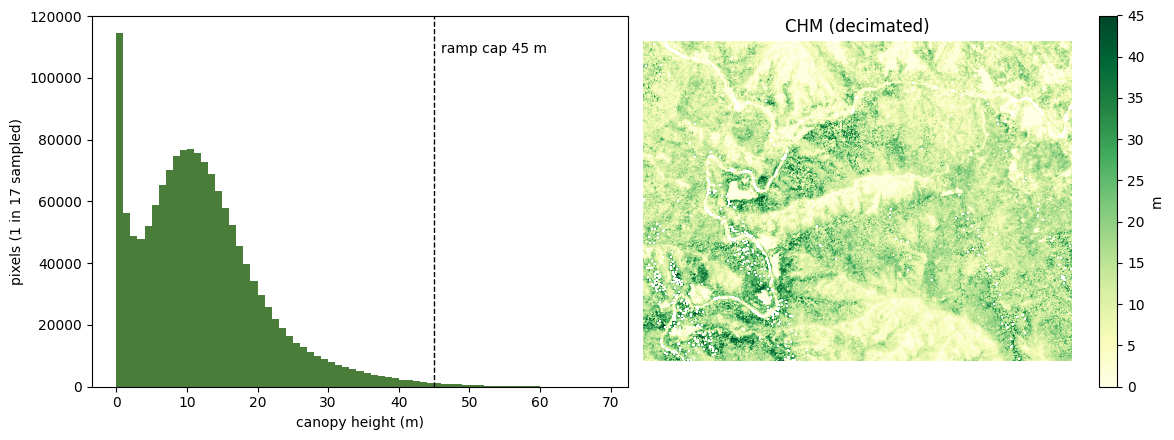

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.hist(v[::17], bins=np.arange(0, 70, 1), color="#4a7c3a")
ax1.axvline(45, color="k", ls="--", lw=1); ax1.text(46, ax1.get_ylim()[1] * 0.9, "ramp cap 45 m")
ax1.set_xlabel("canopy height (m)"); ax1.set_ylabel("pixels (1 in 17 sampled)")
step = max(1, chm.shape[0] // 600)
im = ax2.imshow(chm[::step, ::step].filled(np.nan), cmap="YlGn", vmin=0, vmax=45)
ax2.set_title("CHM (decimated)"); ax2.axis("off"); fig.colorbar(im, ax=ax2, label="m")
fig.tight_layout()

## Write the canopy-height COG

Creation options, and why:

* **EPSG:3857** — MapLibre's COG source wants Web Mercator; reprojecting here means no work at view time.
* **DEFLATE** — must stay decodable by geotiff.js in the browser (DEFLATE / LZW / JPEG). WEBP writes
  fine from GDAL and then fails *silently* in MapLibre.
* **predictor=3** — floating-point predictor; shrinks a float32 surface substantially.
* **512 px blocks + overviews** — what makes it "cloud-optimised": the browser fetches only the
  tiles and zoom level it is drawing.
* **bilinear** resampling — right for a continuous surface.

In [4]:
COG_OPTS = dict(driver="COG", compress="DEFLATE", blocksize=512, target_srs="EPSG:3857")

profile.update(dtype="float32", nodata=-9999.0, compress="DEFLATE", tiled=True, blockxsize=512, blockysize=512)
chm_utm = CACHE / "chm_utm.tif"
with rasterio.open(chm_utm, "w", **profile) as out:
    out.write(chm.filled(-9999.0), 1)
chm_cog = CACHE / "sfe_canopy_height_lidar.cog.tif"
rio_copy(chm_utm, chm_cog, resampling="BILINEAR", overview_resampling="BILINEAR", predictor=3, **COG_OPTS)
del a, b, diff, chm, v

## MTBS burn severity → RGBA COG

MTBS "dNBR6" rasters are thematic: each pixel is a class, and the file carries its own colour table.

| Class | Meaning |
|---|---|
| 0 | Background (outside the mapped area) |
| 1 | Unburned to low |
| 2 | Low |
| 3 | Moderate |
| 4 | High |
| 5 | Increased greenness |
| 6 | Non-processing area (cloud, shadow) |

The webmap's `cog_color` ramps are for continuous data, so instead of colouring at render time we
**expand the embedded palette to RGBA** here: classes 1–6 get MTBS's own colours, everything else is
transparent (alpha 0). Resampling is **nearest** — averaging class numbers is meaningless.

class counts: {0: 189945, 1: 9010, 2: 35591, 3: 7217, 4: 4098, 5: 51}


Text(0.5, 1.0, 'MTBS dNBR6 as RGBA')

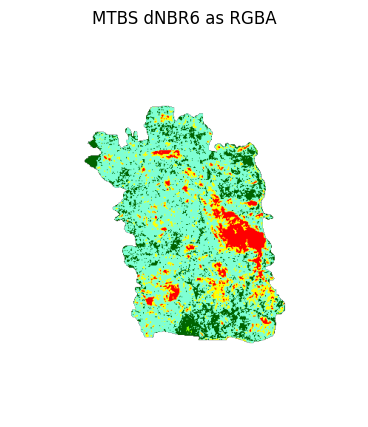

In [5]:
with rasterio.open(mtbs_p) as src:
    cls = src.read(1)
    cmap = src.colormap(1)
    mprofile = src.profile.copy()
print("class counts:", {int(k): int((cls == k).sum()) for k in np.unique(cls)})

valid = (cls >= 1) & (cls <= 6)
rgba = np.zeros((4,) + cls.shape, dtype="uint8")
for value, (r, g, b_, _) in cmap.items():
    m = valid & (cls == value)
    rgba[0][m], rgba[1][m], rgba[2][m] = r, g, b_
rgba[3][valid] = 255

mprofile.update(count=4, dtype="uint8", photometric="RGB", alpha="YES", nodata=None, compress="DEFLATE")
mprofile.pop("colormap", None)
mtbs_rgba = CACHE / "mtbs_rgba.tif"
with rasterio.open(mtbs_rgba, "w", **mprofile) as out:
    out.write(rgba)
mtbs_cog = CACHE / "sfe_mtbs.cog.tif"
rio_copy(mtbs_rgba, mtbs_cog, resampling="NEAREST", overview_resampling="NEAREST", **COG_OPTS)

plt.figure(figsize=(5, 5)); plt.imshow(np.moveaxis(rgba, 0, -1)); plt.axis("off"); plt.title("MTBS dNBR6 as RGBA")

## Check against what's published

If the inputs haven't changed, the rebuilt COGs should match the published ones in grid, bounds and
band layout (byte-identical files aren't expected — GDAL versions differ in metadata).

In [6]:
for local, name in ((chm_cog, "sfe_canopy_height_lidar"), (mtbs_cog, "sfe_mtbs")):
    url = f"/vsicurl/{PUBLISHED}{name}/{name}.cog.tif"
    with rasterio.open(local) as l, rasterio.open(url) as p:
        same = (l.crs == p.crs and l.shape == p.shape and l.count == p.count
                and np.allclose(l.bounds, p.bounds) and l.overviews(1) == p.overviews(1))
        print(f"{name:24s} local {l.width}x{l.height}x{l.count} {l.dtypes[0]}  "
              f"published {p.width}x{p.height}x{p.count}  match={same}")
        print(" " * 25, "bounds (lon/lat):", [round(x, 4) for x in transform_bounds(l.crs, "EPSG:4326", *l.bounds)])

sfe_canopy_height_lidar  local 5846x4405x1 float32  published 5846x4405x1  match=True
                          bounds (lon/lat): [-123.6518, 39.7268, -123.5835, 39.7663]


sfe_mtbs                 local 604x628x4 uint8  published 604x628x4  match=True
                          bounds (lon/lat): [-123.7596, 39.6986, -123.5469, 39.8686]


## Publish (optional)

Uploads to the shared `sources/rasters/` prefix, which the bucket policy makes publicly readable.
The layer's `cog_url` points there, so the webmap picks up a new file on next load — no
re-materialize needed. The `aws` CLI needs the `atlas` profile (or any credentials with write access
to `scs-atlas-data`).

In [7]:
if UPLOAD:
    for local, name in ((chm_cog, "sfe_canopy_height_lidar"), (mtbs_cog, "sfe_mtbs")):
        dest = f"s3://scs-atlas-data/sources/rasters/{name}/{name}.cog.tif"
        subprocess.run(["aws", "s3", "cp", str(local), dest, "--profile", os.environ.get("AWS_PROFILE", "atlas"),
                        "--content-type", "image/tiff"], check=True)
        print("uploaded", dest)
else:
    print("Not uploading — set UPLOAD_COGS=1 to publish. Built files are in", CACHE)

Not uploading — set UPLOAD_COGS=1 to publish. Built files are in ~/.cache/atlas_notebooks/sfe_rasters
